In [29]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import time
import pandas as pd

def configurar_entorno():
    """
    Descripción: Verifica la disponibilidad de la GPU en el entorno de ejecución para acelerar el entrenamiento.
    Restricciones: Depende de la asignación de recursos del entorno (ej. Google Colab).
    Entradas: Ninguna.
    Salidas:
        - gpu_disponible (bool): Verdadero si hay una GPU configurada y lista.
    """
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"GPU detectada y configurada: {gpus[0]}")
        return True
    else:
        print("ADVERTENCIA: No se detectó GPU. El entrenamiento se realizará en CPU y será lento.")
        return False

gpu_lista = configurar_entorno()

GPU detectada y configurada: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [3]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

def preparar_datos(batch_size):
    """
    Descripción:
        Descarga CIFAR-100, normaliza los píxeles, aplica aumento de datos
        y divide el dataset en entrenamiento, validación y prueba.

    Restricciones:
        - El conjunto de validación se extrae del conjunto de entrenamiento (20%).
        - Esta función NO visualiza imágenes.

    Entradas:
        - batch_size (int): Tamaño del lote de datos.

    Salidas:
        - train_ds (tf.data.Dataset): Dataset de entrenamiento optimizado con augmentation.
        - val_ds (tf.data.Dataset): Dataset de validación.
        - test_ds (tf.data.Dataset): Dataset de prueba.
        - x_train, y_train: Datos crudos de entrenamiento (sin augmentation).
        - x_test, y_test: Datos crudos de prueba.
        - data_augmentation: Pipeline de augmentation.
        - class_names: Nombres de las clases.
    """

    # Cargar CIFAR-100 con etiquetas finas
    (x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar100.load_data(
        label_mode='fine'
    )

    # Nombres de las clases
    class_names = tf.keras.datasets.cifar100.load_data(label_mode='fine')[0]

    # Normalización (0 a 1)
    x_train_full = x_train_full / 255.0
    x_test = x_test / 255.0

    # División de entrenamiento y validación (80% - 20%)
    val_split = int(0.2 * len(x_train_full))

    x_val = x_train_full[:val_split]
    y_val = y_train_full[:val_split]

    x_train = x_train_full[val_split:]
    y_train = y_train_full[val_split:]

    # Pipeline de tf.data para rendimiento óptimo
    AUTOTUNE = tf.data.AUTOTUNE

    # Aumento de datos (Data Augmentation) solo para entrenamiento
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ])

    def augment(image, label):
        """
        Descripción:
            Aplica transformaciones aleatorias a una imagen sin cambiar su etiqueta.
        """
        imagen_aumentada = data_augmentation(image, training=True)
        return imagen_aumentada, label

    # Dataset de entrenamiento con augmentation
    train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
    train_ds = train_ds.shuffle(10000)
    train_ds = train_ds.batch(batch_size)
    train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)
    train_ds = train_ds.prefetch(AUTOTUNE)

    # Dataset de validación
    val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
    val_ds = val_ds.batch(batch_size).prefetch(AUTOTUNE)

    # Dataset de prueba
    test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
    test_ds = test_ds.batch(batch_size).prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds, x_train, y_train, x_test, y_test, data_augmentation

In [4]:
def visualizar_dataset(x_data, y_data, data_augmentation=None, cantidad=9, mostrar_augment=False):
    """
    Descripción:
        Visualiza imágenes del dataset original o imágenes con augmentation.

    Entradas:
        - x_data: Imágenes.
        - y_data: Etiquetas.
        - data_augmentation: Pipeline de augmentation.
        - cantidad (int): Número de imágenes a mostrar.
        - mostrar_augment (bool):
            False -> muestra imágenes originales
            True  -> muestra original vs augmentada
    """

    if not mostrar_augment:

        plt.figure(figsize=(10, 10))

        for i in range(cantidad):
            ax = plt.subplot(int(np.ceil(cantidad / 3)), 3, i + 1)
            plt.imshow(x_data[i])
            plt.title(f"Clase: {y_data[i][0]}")
            plt.axis("off")

        plt.suptitle("Ejemplos visuales de CIFAR-100")
        plt.show()

    else:

        plt.figure(figsize=(8, cantidad * 3))

        for i in range(cantidad):

            imagen_original = x_data[i]
            etiqueta = y_data[i][0]

            imagen_augmentada = data_augmentation(
                tf.expand_dims(imagen_original, axis=0),
                training=True
            )[0]

            ax = plt.subplot(cantidad, 2, 2 * i + 1)
            plt.imshow(imagen_original)
            plt.title(f"Original | Clase: {etiqueta}")
            plt.axis("off")

            ax = plt.subplot(cantidad, 2, 2 * i + 2)
            plt.imshow(imagen_augmentada.numpy())
            plt.title(f"Augment | Clase: {etiqueta}")
            plt.axis("off")

        plt.suptitle("Original vs Data Augmentation")
        plt.tight_layout()
        plt.show()

BATCH_SIZE = 64

train_ds, val_ds, test_ds, x_train, y_train, x_test, y_test, data_augmentation = preparar_datos(BATCH_SIZE)

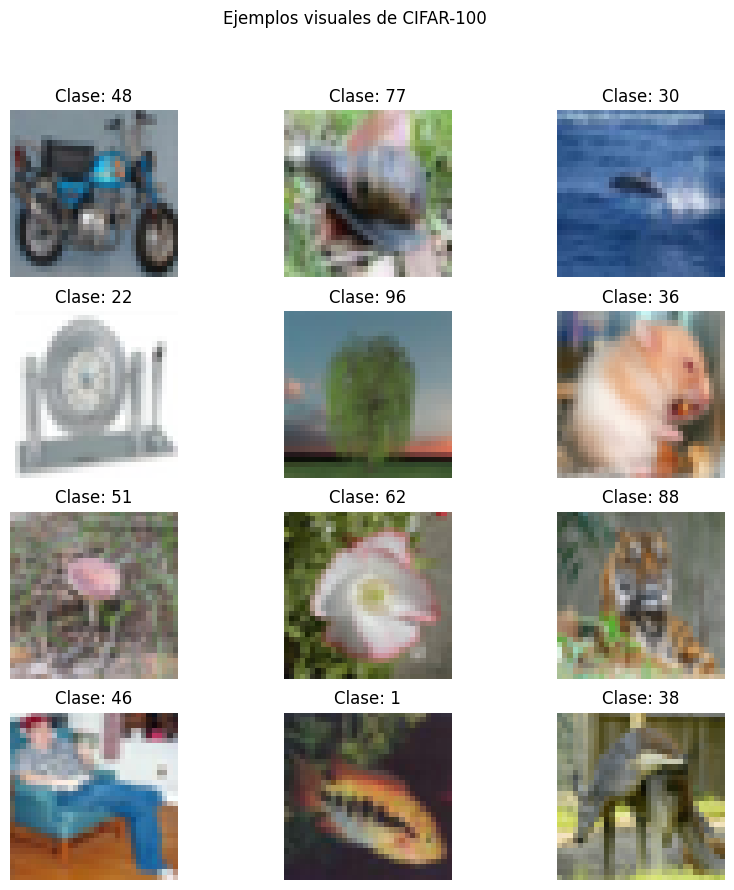

In [5]:
visualizar_dataset(
    x_train,
    y_train,
    cantidad=12,
    mostrar_augment=False
)

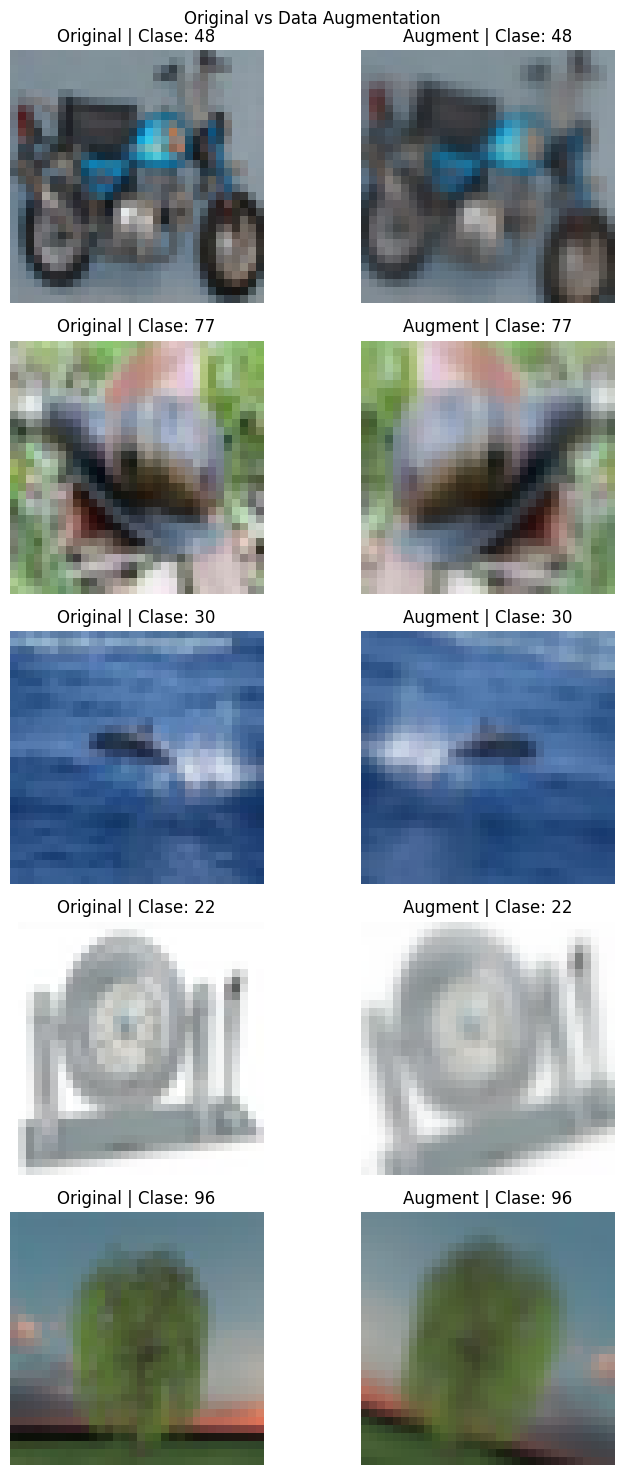

In [6]:
visualizar_dataset(
    x_train,
    y_train,
    data_augmentation=data_augmentation,
    cantidad=5,
    mostrar_augment=True
)

In [16]:
class CNN_Modelo(models.Model):
    """
    Descripción:
        Red neuronal convolucional configurable para experimentación
        con distintos hiperparámetros.

    Restricciones:
        - Permite activar o desactivar Batch Normalization y Dropout.
        - Padding puede ser 'same' o 'valid'.

    Entradas:
        Tensor de imágenes (N, 32, 32, 3)

    Salidas:
        Tensor de logits para 100 clases
    """

    def __init__(
        self,
        filtros1=32,
        filtros2=64,
        unidades_fc=512,
        usar_batchnorm=False,
        usar_dropout=False,
        dropout_rate=0.5,
        padding='same'
    ):
        super(CNN_Modelo, self).__init__()

        self.usar_batchnorm = usar_batchnorm
        self.usar_dropout = usar_dropout

        # Bloque convolucional 1
        self.conv1 = layers.Conv2D(
            filtros1,
            (3, 3),## ESTO ES EL KERNEL
            padding=padding
        )

        self.bn1 = layers.BatchNormalization()
        self.pool1 = layers.MaxPooling2D((2, 2))

        # Bloque convolucional 2
        self.conv2 = layers.Conv2D(
            filtros2,
            (3, 3),
            padding=padding
        )

        self.bn2 = layers.BatchNormalization()
        self.pool2 = layers.MaxPooling2D((2, 2))

        # Bloque fully connected
        self.flatten = layers.Flatten()

        self.fc1 = layers.Dense(unidades_fc)
        self.bn3 = layers.BatchNormalization()

        self.dropout = layers.Dropout(dropout_rate)

        self.fc2 = layers.Dense(100)

    def call(self, inputs, training=False):

        x = self.conv1(inputs)

        if self.usar_batchnorm:
            x = self.bn1(x, training=training)

        x = tf.nn.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)

        if self.usar_batchnorm:
            x = self.bn2(x, training=training)

        x = tf.nn.relu(x)
        x = self.pool2(x)

        x = self.flatten(x)
        x = self.fc1(x)

        if self.usar_batchnorm:
            x = self.bn3(x, training=training)

        x = tf.nn.relu(x)

        if self.usar_dropout:
            x = self.dropout(x, training=training)

        return self.fc2(x)

def mostrar_arquitectura(modelo, nombre):
    """
    Descripción:
        Construye el modelo e imprime su arquitectura.
    """
    print(f"\n--- Arquitectura de {nombre} ---")
    modelo.build((None, 32, 32, 3))
    modelo.summary()



In [17]:
# Configuración 1: Modelo base sin regularización
modelo1 = CNN_Modelo(filtros1=32, filtros2=64, unidades_fc=256,
                     usar_batchnorm=False, usar_dropout=False)

# Configuración 2: Modelo intermedio con regularización (BatchNorm + Dropout)
modelo2 = CNN_Modelo(filtros1=64, filtros2=128, unidades_fc=512,
                     usar_batchnorm=True, usar_dropout=True, dropout_rate=0.4)

# Configuración 3: Modelo complejo con mayor capacidad y regularización fuerte
modelo3 = CNN_Modelo(filtros1=128, filtros2=256, unidades_fc=1024,
                     usar_batchnorm=True, usar_dropout=True, dropout_rate=0.5)

mostrar_arquitectura(modelo1, "CNN 1 (Básica)")
mostrar_arquitectura(modelo2, "CNN 2 (Regularizada)")
mostrar_arquitectura(modelo3, "CNN 3 (Compleja)")


--- Arquitectura de CNN 1 (Básica) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'cnn__modelo_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "cnn__modelo_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

Model: "cnn__modelo_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
def compilar_y_entrenar(modelo, train_ds, val_ds, epocas, learning_rate=0.001):
    """
    Descripción: Configura los optimizadores, la pérdida y ejecuta el entrenamiento del modelo.
    Restricciones: Asume etiquetas enteras, por lo que utiliza SparseCategoricalCrossentropy.
    Entradas: Modelo instanciado, datasets de entrenamiento y validación, número de épocas y tasa de aprendizaje.
    Salidas: Objeto history con el registro de métricas.
    """
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    modelo.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
    ]

    history = modelo.fit(train_ds, validation_data=val_ds, epochs=epocas, callbacks=callbacks)
    return history

In [20]:
# Esta usa GPU y sí se tarda aguas.
EPOCAS_MAXIMAS = 30 # El EarlyStopping detendrá el entrenamiento antes si el modelo deja de mejorar

print("\n=== INICIANDO ENTRENAMIENTO: CNN 1 ===")
historial1 = compilar_y_entrenar(modelo1, train_ds, val_ds, EPOCAS_MAXIMAS)

print("\n=== INICIANDO ENTRENAMIENTO: CNN 2 ===")
historial2 = compilar_y_entrenar(modelo2, train_ds, val_ds, EPOCAS_MAXIMAS)

print("\n=== INICIANDO ENTRENAMIENTO: CNN 3 ===")
historial3 = compilar_y_entrenar(modelo3, train_ds, val_ds, EPOCAS_MAXIMAS)


=== INICIANDO ENTRENAMIENTO: CNN 1 ===
Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.1195 - loss: 3.8468 - val_accuracy: 0.1897 - val_loss: 3.3601 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.2205 - loss: 3.2258 - val_accuracy: 0.2415 - val_loss: 3.1053 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.2650 - loss: 2.9903 - val_accuracy: 0.2729 - val_loss: 2.9120 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.2939 - loss: 2.8358 - val_accuracy: 0.2901 - val_loss: 2.8373 - learning_rate: 0.0010
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.3183 - loss: 2.7273 - val_accuracy: 0.3098 - val_loss: 2.7536 - learning_rate: 0.0010
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.3299 - loss: 2.6451 - val_accuracy: 0.3115 - val_loss: 2.7606 - learning_rate: 0.0010
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━

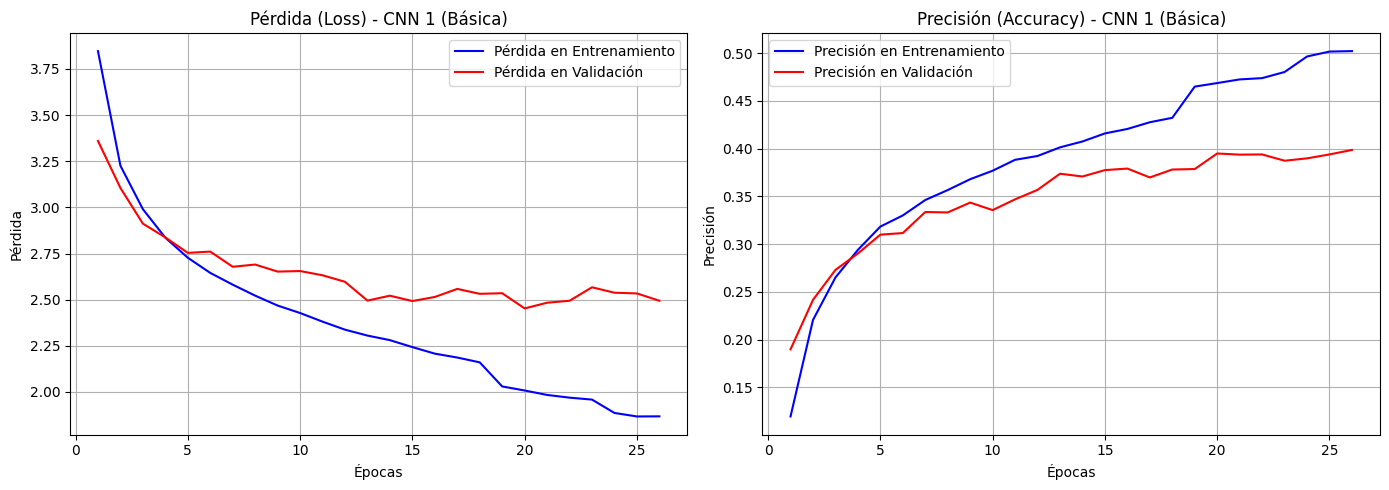

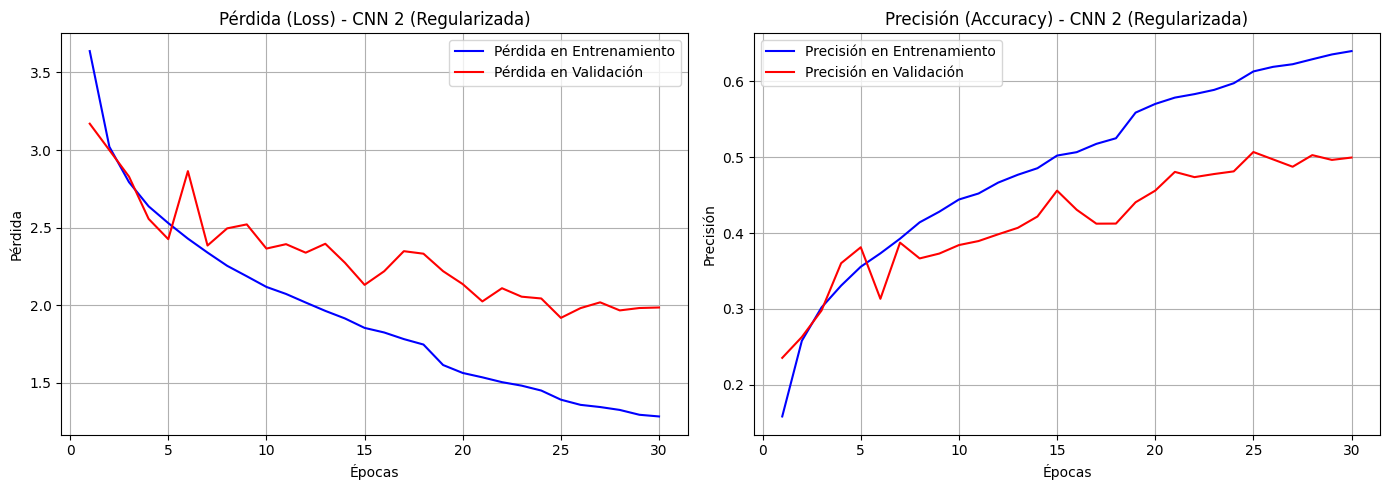

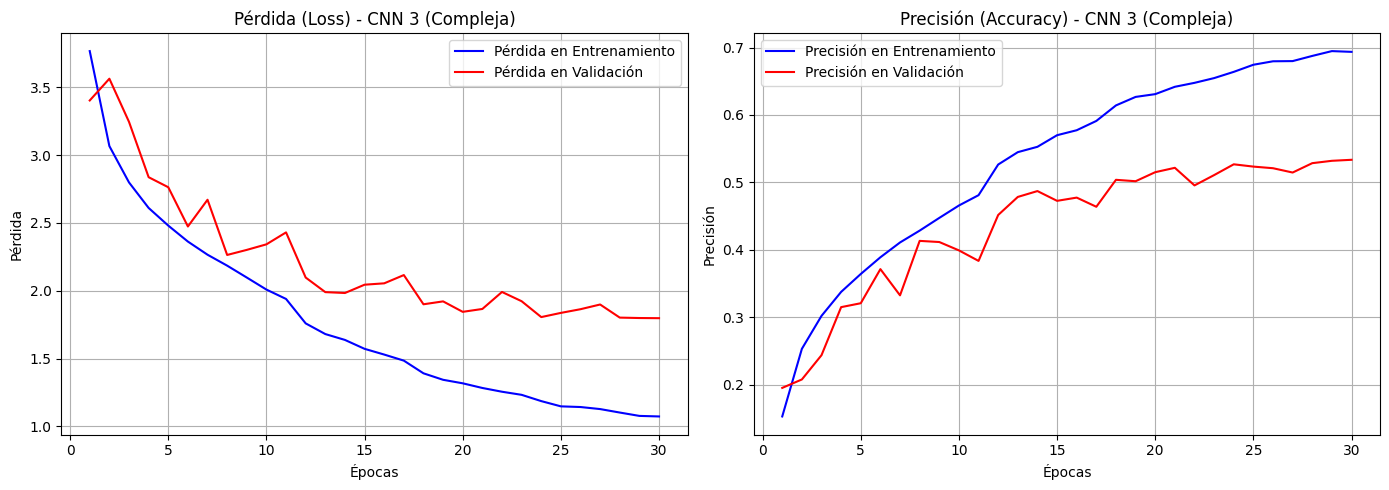

In [23]:
def graficar_entrenamiento(history, nombre_modelo):
    """
    Descripción: Genera gráficas comparativas de pérdida y precisión entre entrenamiento y validación para diagnosticar sobreajuste.
    Restricciones: Requiere el objeto devuelto por model.fit().
    Entradas:
        - history: Historial de entrenamiento.
        - nombre_modelo (str): Nombre del modelo.
    Salidas: Ninguna (Muestra la gráfica).
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epocas_rango = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Gráfica de Loss
    plt.subplot(1, 2, 1)
    plt.plot(epocas_rango, loss, 'b-', label='Pérdida en Entrenamiento')
    plt.plot(epocas_rango, val_loss, 'r-', label='Pérdida en Validación')
    plt.title(f'Pérdida (Loss) - {nombre_modelo}')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.grid(True)

    # Gráfica de Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epocas_rango, acc, 'b-', label='Precisión en Entrenamiento')
    plt.plot(epocas_rango, val_acc, 'r-', label='Precisión en Validación')
    plt.title(f'Precisión (Accuracy) - {nombre_modelo}')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
graficar_entrenamiento(historial1, "CNN 1 (Básica)")
graficar_entrenamiento(historial2, "CNN 2 (Regularizada)")
graficar_entrenamiento(historial3, "CNN 3 (Compleja)")

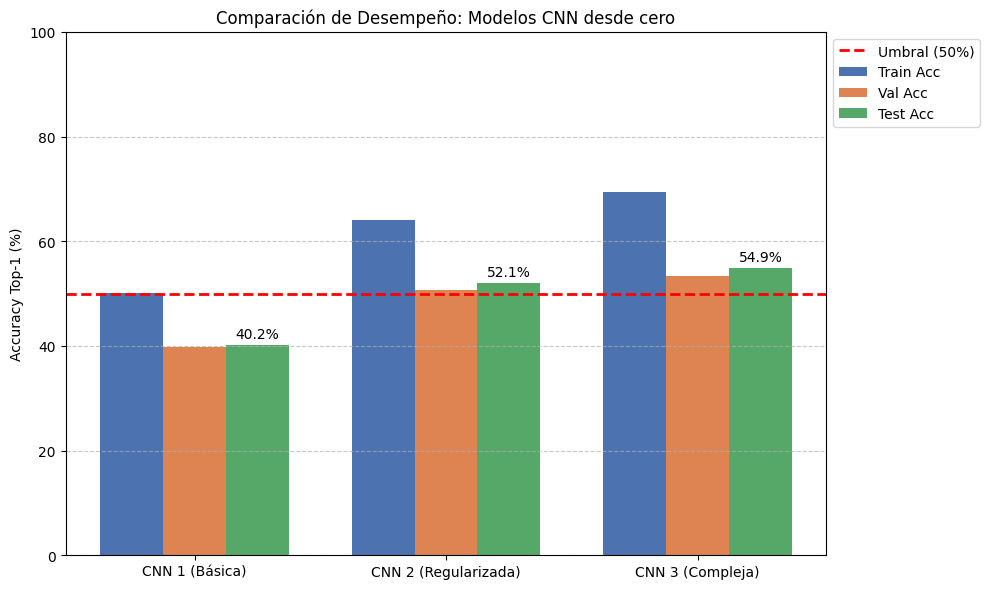

In [31]:
def graficar_comparacion_final(df):
    """
    Descripción:
        Genera un gráfico de barras agrupadas comparando las métricas de
        Entrenamiento, Validación y Prueba de los modelos evaluados,
        incluyendo una línea de umbral.

    Restricciones:
        Requiere el DataFrame generado por la función evaluar_y_comparar.

    Entradas:
        - df (pd.DataFrame): Tabla con las métricas finales.

    Salidas:
        Ninguna (Despliega la gráfica en la interfaz).
    """
    train_acc = df['Acc. Train (%)'].astype(float)
    val_acc = df['Acc. Val (%)'].astype(float)
    test_acc = df['Acc. Test (%)'].astype(float)
    nombres = df['Configuración']

    x = np.arange(len(nombres))
    width = 0.25  # Ancho de las barras

    fig, ax = plt.subplots(figsize=(10, 6))

    # Dibujar las barras para cada métrica
    rects1 = ax.bar(x - width, train_acc, width, label='Train Acc', color='#4C72B0')
    rects2 = ax.bar(x, val_acc, width, label='Val Acc', color='#DD8452')
    rects3 = ax.bar(x + width, test_acc, width, label='Test Acc', color='#55A868')

    # Línea del umbral del 50%
    ax.axhline(y=50.0, color='r', linestyle='--', linewidth=2, label='Umbral (50%)')

    # Etiquetas y diseño
    ax.set_ylabel('Accuracy Top-1 (%)')
    ax.set_title('Comparación de Desempeño: Modelos CNN desde cero')
    ax.set_xticks(x)
    ax.set_xticklabels(nombres)
    ax.set_ylim(0, 100) # El eje Y va de 0 a 100%
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    # Agregar los numeritos encima de la barra de 'Test' para ver el resultado final
    ax.bar_label(rects3, padding=3, fmt='%.1f%%')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Ejecutar la gráfica usando tu tabla de resultados
graficar_comparacion_final(df_comparacion)


Generando visualización de predicciones para: CNN 3 (Compleja)...


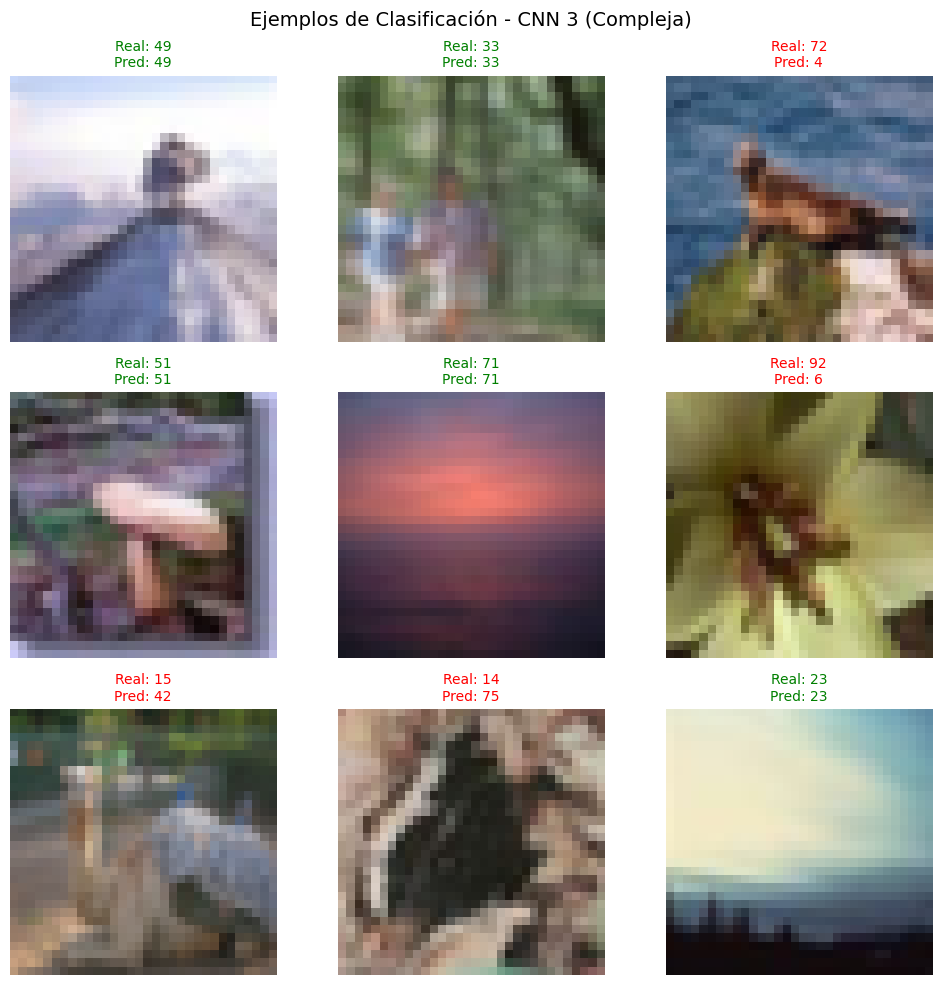

In [33]:

def visualizar_predicciones(modelo, test_ds, nombre_modelo, num_ejemplos=9):
    """
    Descripción:
        Extrae un lote de imágenes del conjunto de prueba, realiza inferencia con
        el modelo indicado y grafica los resultados comparando la predicción con
        la etiqueta real.

    Restricciones:
        El parámetro num_ejemplos debe ser menor o igual al tamaño del lote (batch_size)
        y preferentemente un cuadrado perfecto (9, 16, 25) para la cuadrícula.

    Entradas:
        - modelo: Instancia del modelo entrenado a evaluar.
        - test_ds (tf.data.Dataset): Dataset de prueba.
        - nombre_modelo (str): Nombre del modelo para el título.
        - num_ejemplos (int): Cantidad de imágenes a desplegar.

    Salidas:
        Ninguna (Despliega la cuadrícula de imágenes en la interfaz).
    """
    print(f"\nGenerando visualización de predicciones para: {nombre_modelo}...")

    # Extraer un solo lote (batch) del dataset de prueba
    for imagenes, etiquetas_reales in test_ds.take(1):
        # Hacer la predicción con el modelo seleccionado
        predicciones_prob = modelo.predict(imagenes, verbose=0)
        etiquetas_predichas = np.argmax(predicciones_prob, axis=1)

        # Ajustar el tamaño de la figura dependiendo de la cantidad de ejemplos
        filas_cols = int(np.ceil(np.sqrt(num_ejemplos)))
        plt.figure(figsize=(10, 10))

        for i in range(num_ejemplos):
            ax = plt.subplot(filas_cols, filas_cols, i + 1)

            # La imagen está normalizada entre 0 y 1, imshow la procesa sin problemas
            plt.imshow(imagenes[i].numpy())

            real = etiquetas_reales[i].numpy()[0]
            pred = etiquetas_predichas[i]

            # Determinar color: Verde si es correcto, Rojo si falló
            color = 'green' if real == pred else 'red'

            plt.title(f"Real: {real}\nPred: {pred}", color=color, fontsize=10)
            plt.axis("off")

        plt.suptitle(f"Ejemplos de Clasificación - {nombre_modelo}", fontsize=14)
        plt.tight_layout()
        plt.show()

        # Romper el ciclo después del primer lote
        break

# Aquí puedes llamar a la función pasándole el modelo que quieras revisar.
# Por ejemplo, para ver cómo le fue al modelo más complejo:
visualizar_predicciones(modelo3, test_ds, "CNN 3 (Compleja)")

# Si quieres comparar visualmente con el modelo básico, solo descomenta la siguiente línea:
# visualizar_predicciones(modelo1, test_ds, "CNN 1 (Básica)")


Generando predicciones para Matriz de Confusión de CNN 3 (Compleja)...
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


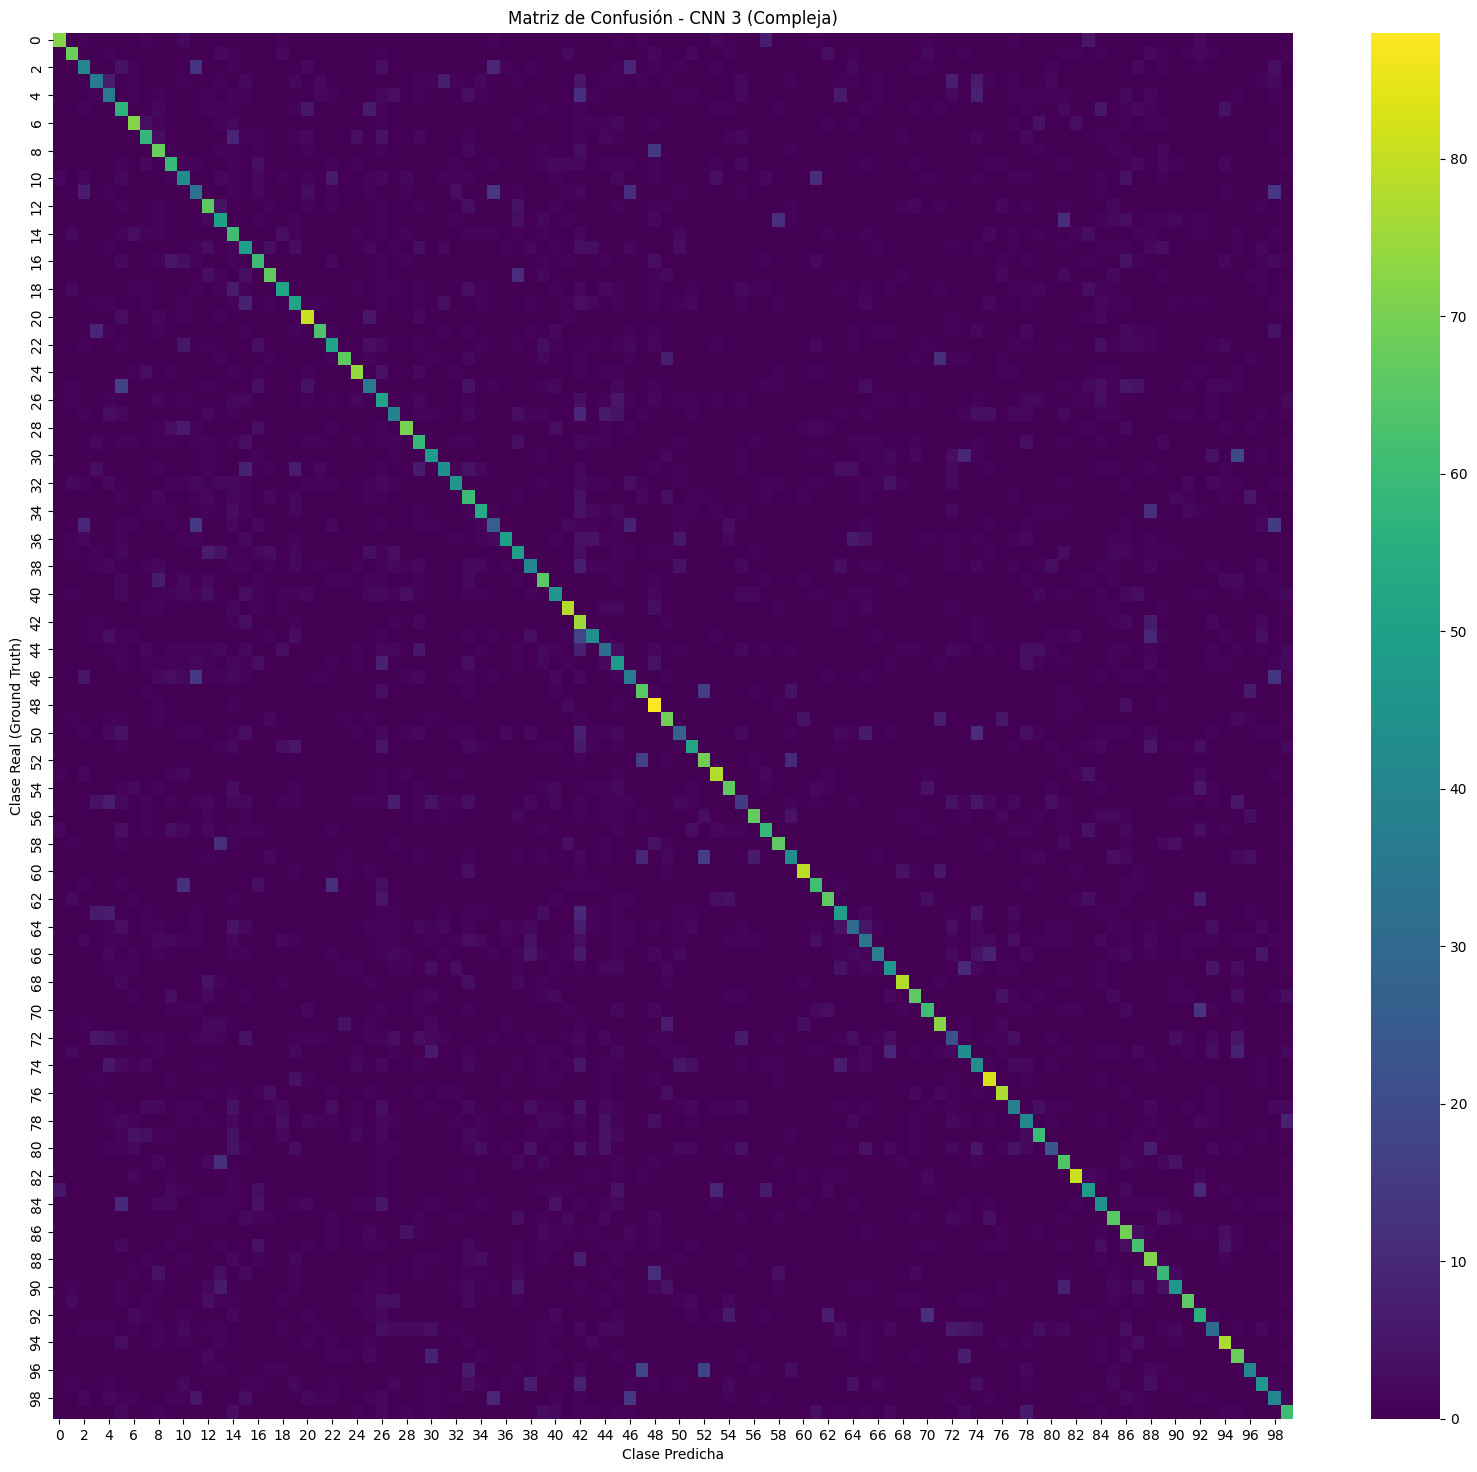

In [32]:
def generar_matriz_confusion(modelo, test_ds, y_true, nombre_modelo):
    """
    Descripción: Calcula y despliega la matriz de confusión para evaluar qué clases confunde el modelo entre las 100 disponibles.
    Restricciones: La visualización es de alta densidad debido al número de categorías.
    Entradas:
        - modelo: Modelo ya entrenado.
        - test_ds: Dataset de prueba.
        - y_true: Arreglo de etiquetas reales.
        - nombre_modelo (str): Nombre del modelo a evaluar.
    Salidas: Ninguna (Muestra mapa de calor).
    """
    print(f"\nGenerando predicciones para Matriz de Confusión de {nombre_modelo}...")

    # Obtener predicciones (logits)
    predicciones = modelo.predict(test_ds)
    # Seleccionar la clase con la probabilidad más alta
    y_pred = np.argmax(predicciones, axis=1)

    # Calcular matriz
    cm = confusion_matrix(y_true, y_pred)

    # Graficar
    plt.figure(figsize=(20, 18))
    sns.heatmap(cm, cmap='viridis', annot=False, cbar=True)
    plt.title(f'Matriz de Confusión - {nombre_modelo}')
    plt.xlabel('Clase Predicha')
    plt.ylabel('Clase Real (Ground Truth)')
    plt.show()

# Suponiendo que el Modelo 2 resulta ser el mejor por sus capas de regularización:
generar_matriz_confusion(modelo3, test_ds, y_test, "CNN 3 (Compleja)")